In [1]:
import pickle
import numpy as np
with open('D:/amc/data/RML2016.10a_dict.pkl', 'rb') as f:
    data = pickle.load(f, encoding='latin1')
print(f"Total (modulation, SNR) pairs: {len(data)}")
print(f"Exp keys: {list(data.keys())[:5]}")

Total (modulation, SNR) pairs: 220
Exp keys: [('QPSK', 2), ('PAM4', 8), ('AM-DSB', -4), ('GFSK', 6), ('QAM64', 8)]


In [2]:
sample_key = ('QPSK',2)
sample_data = data[sample_key]
print(f"Shape of data for {sample_key}: {sample_data.shape}")
print(f"Data type: {sample_data.dtype}")

Shape of data for ('QPSK', 2): (1000, 2, 128)
Data type: float32


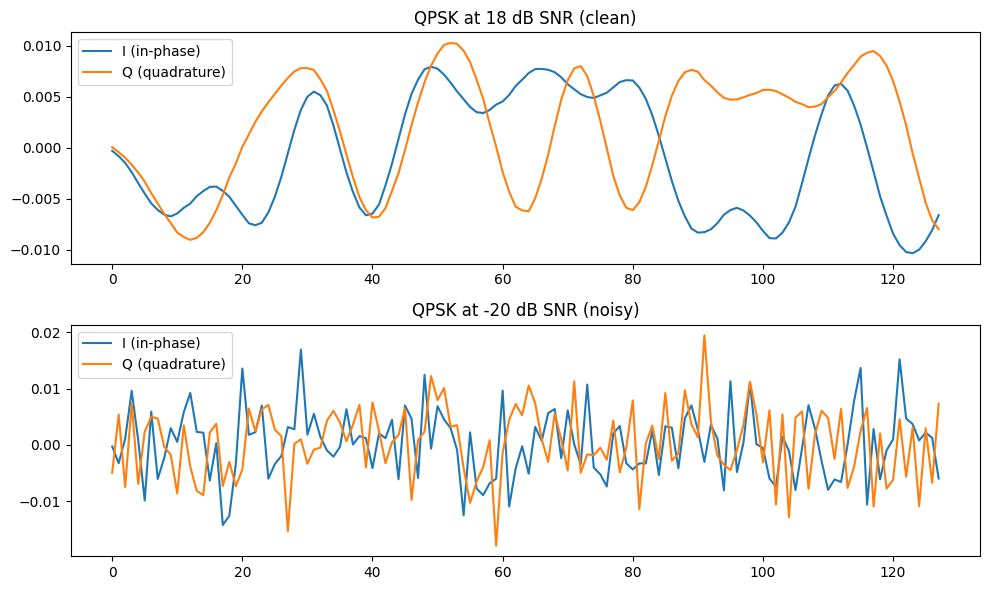

In [3]:
import matplotlib.pyplot as plt
mod = 'QPSK'
clean_snr = 18
noisy_snr = -20

clean_signal = data[(mod, clean_snr)][0]
noisy_signal = data[(mod, noisy_snr)][0]

fig,axes = plt.subplots(2,1,figsize=(10,6))
axes[0].plot(clean_signal[0],label = 'I (in-phase)')
axes[0].plot(clean_signal[1],label = 'Q (quadrature)')
axes[0].set_title(f'{mod} at {clean_snr} dB SNR (clean)')
axes[0].legend()
axes[1].plot(noisy_signal[0], label='I (in-phase)')
axes[1].plot(noisy_signal[1], label='Q (quadrature)')
axes[1].set_title(f'{mod} at {noisy_snr} dB SNR (noisy)')
axes[1].legend()
plt.tight_layout()
plt.show()

In [4]:
mod_list =sorted(set([k[0] for k in data.keys()]))
snr_list = sorted(set([k[1] for k in data.keys()]))
print(f"modulation list: ({len(mod_list)}) : {mod_list}")
print(f"SNR levels ({len(snr_list)}) : {snr_list}")

X = []
y = []
snr = []
for (mod,s), signals in data.items():
    X.append(signals)
    y.extend([mod]*signals.shape[0])
    snr.extend([s]*signals.shape[0])
X = np.vstack(X)
y = np.array(y)
snr= np.array(snr)
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"snr shape: {snr.shape}")



modulation list: (11) : ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
SNR levels (20) : [-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]

X shape: (220000, 2, 128)
y shape: (220000,)
snr shape: (220000,)


In [5]:
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()
y_encoded= le.fit_transform(y)
print(f"Classes: {le.classes_}")
print(f"Encoded example: {y[0]} -> {y_encoded[0]}")

Classes: ['8PSK' 'AM-DSB' 'AM-SSB' 'BPSK' 'CPFSK' 'GFSK' 'PAM4' 'QAM16' 'QAM64'
 'QPSK' 'WBFM']
Encoded example: QPSK -> 9


In [6]:
from sklearn.model_selection import train_test_split
strat_key= np.array([f"{mod}_{s}" for mod,s in zip(y,snr)])
X_train,X_temp,y_train,y_temp,snr_train,snr_temp, strat_train,strat_temp = train_test_split(X,y_encoded,snr,strat_key, test_size=0.3,random_state=42, stratify=strat_key)
X_val,X_test,y_val,y_test,snr_val,snr_test = train_test_split(X_temp,y_temp,snr_temp,test_size=0.5,random_state=42, stratify=strat_temp)
print(f"Train: {X_train.shape[0]} samples")
print(f"Val: {X_val.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

Train: 154000 samples
Val: 33000 samples
Test: 33000 samples


In [7]:
import os
os.makedirs('../data/processed', exist_ok=True)
np.save('../data/processed/X_train.npy', X_train)
np.save('../data/processed/X_val.npy', X_val)
np.save('../data/processed/X_test.npy', X_test)
np.save('../data/processed/y_train.npy', y_train)
np.save('../data/processed/y_val.npy', y_val)
np.save('../data/processed/y_test.npy', y_test)
np.save('../data/processed/snr_train.npy', snr_train)
np.save('../data/processed/snr_val.npy', snr_val)
np.save('../data/processed/snr_test.npy', snr_test)

print("Saved all splits to ../data/processed/")

Saved all splits to ../data/processed/
